In [1]:
%load_ext autoreload
    
%cd /workdir/ComfyUI/
%autoreload 2

/workdir/ComfyUI


In [2]:
%set_env TORCH_CUDA_ARCH_LIST="7.5 8.0 8.6 8.9+PTX"

env: TORCH_CUDA_ARCH_LIST="7.5 8.0 8.6 8.9+PTX"


In [3]:
from custom_nodes.comfywr_pytorch_renderkit.meshes.cuboid import Cuboid
from custom_nodes.comfywr_pytorch_renderkit.meshes.roofed_building import RoofedBuilding
from custom_nodes.comfywr_pytorch_renderkit.cameras.parametric_camera import ParametricCamera
from custom_nodes.comfywr_pytorch_renderkit.transforms.transform import Transform

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import torch
import numpy as np
from PIL import Image
from pytorch3d.renderer import MeshRasterizer, RasterizationSettings, SoftSilhouetteShader, MeshRenderer

import matplotlib.pyplot as plt

In [5]:
import torch
import torch.nn.functional as F
from torchvision.transforms.functional import gaussian_blur

In [6]:
import torch
from pytorch3d.renderer import SoftSilhouetteShader, BlendParams, softmax_rgb_blend
from pytorch3d.renderer.mesh.shading import interpolate_face_attributes

from custom_nodes.comfywr_pytorch_renderkit.shaders.depth_with_soft_silhouette import SoftSilhouetteWithDepthShader
from custom_nodes.comfywr_pytorch_renderkit.shaders.normals_with_soft_silhouette import NormalsWithSoftSilhouetteShader
from custom_nodes.comfywr_pytorch_renderkit.utils.compute_normals import compute_normal_map, gaussian_blur

In [7]:
depth_path = "../ComfyUI/output/building_masked_depth_00001_.png"

invalid_depth_weight = 1e-6

depth_size = (256,256)

# Load depth map and mask
depth_img = np.array(Image.open(depth_path).resize(depth_size))
alpha = depth_img[:,:,-1]
depth = torch.from_numpy(depth_img[...,-2:]/255)
alpha = depth[:,:,-1]
dmin, dmax = torch.aminmax(depth.select(-1,0)[depth.select(-1,1) > 0])

normalized_depth = depth.clone()
normalized_depth.select(-1,0).sub_(dmin).div_(dmax-dmin).mul_(depth.select(-1,1)).sub_(1).add_(depth.select(-1,1), alpha=1)
normalized_depth.select(-1,0).clamp_min_(-invalid_depth_weight)

tensor([[-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06],
        [-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06],
        [-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06],
        ...,
        [-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06],
        [-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06],
        [-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06]], dtype=torch.float64)

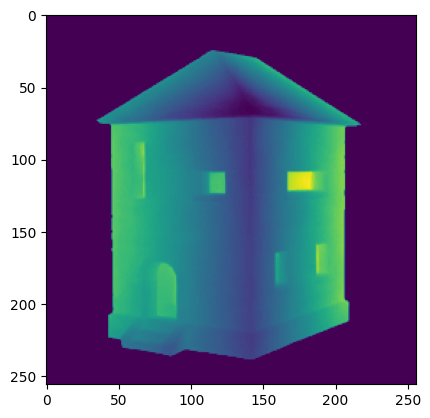

In [8]:
plt.imshow(normalized_depth.select(-1,0))

In [9]:
normalized_depth.amin()

tensor(-1.0000e-06, dtype=torch.float64)

In [10]:
ndepth, nalpha = normalized_depth.permute(2,0,1).float().unflatten(0,(-1,1,1))
normalmap = compute_normal_map(ndepth, nalpha, blur_kernel_size=3, blur_sigma=0.15)
normalmap = gaussian_blur(normalmap, kernel_size=5)
normalmap_rgb = normalmap.add(1).div_(2).mul_(nalpha)#.squeeze().permute(1,2,0)
# normalmap_rgb.select(1,1).clamp_max_(0.5)
normalmap_rgba = torch.cat([normalmap_rgb, nalpha], dim=1)

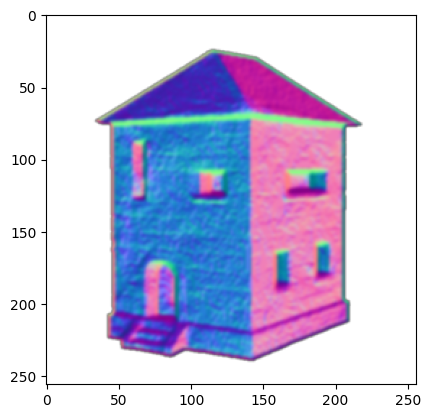

In [11]:
plt.imshow(normalmap_rgba.squeeze().permute(1,2,0))

In [12]:
normalmap_rgb.aminmax()

torch.return_types.aminmax(
min=tensor(0.),
max=tensor(0.9924))

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
depth = depth.to(device)

In [14]:
device

device(type='cuda')

In [15]:
# Rasterization settings for silhouette rendering  
sigma = 1e-6
raster_settings_silhouette = RasterizationSettings(
    image_size=depth.shape[:2], 
    blur_radius=np.log(1. / 1e-4 - 1.)*sigma, 
    faces_per_pixel=5, 
)

# Silhouette renderer 
renderer_normalized_depth = MeshRenderer(
    rasterizer=MeshRasterizer(
        raster_settings=raster_settings_silhouette
    ),
    shader=SoftSilhouetteWithDepthShader(normalize_depth=True, invalid_depth_weight=1e-6)
)

# Normal Map renderer
renderer_normalmap = MeshRenderer(
    rasterizer=MeshRasterizer(
        raster_settings=raster_settings_silhouette
    ),
    shader=NormalsWithSoftSilhouetteShader(camera_relative=True)
)

renderer_silhouette = MeshRenderer(
    rasterizer=MeshRasterizer(
        raster_settings=raster_settings_silhouette
    ),
    shader=SoftSilhouetteShader()
)

rasterizer_silhouette = MeshRasterizer(raster_settings=raster_settings_silhouette)

In [16]:
# Initialize models
transform = Transform(lock_scale=True, lock_rotation=True, lock_translation=True)

# sizes = torch.tensor([3., 2., 6.])
sizes = torch.tensor([3.5, 4, 4.5])
sizes /= sizes.max()

roof_size = (.05, 0.3, 0.2)

lr = 4e-4

fov = 30
distance = 3
# azimuth = 299.0
# elev = 13

azimuth = 35.0
elev = 3.0



camera = ParametricCamera(fov=fov, dist=distance, azim=azimuth, elev=elev, dist_range=(1.,20.)).to(device)
# cuboid = Cuboid(*sizes, transform=transform).to(device)
cuboid = RoofedBuilding(*sizes, roof_size=roof_size,transform=transform).to(device)

# Rasterizer setup
raster_settings = RasterizationSettings(
    image_size=depth.shape[:2], blur_radius=0.0, faces_per_pixel=1
)
rasterizer = MeshRasterizer(raster_settings=raster_settings)

In [17]:
import torch, importlib.util, pathlib, subprocess, re, glob, pytorch3d
print("GPU :", torch.cuda.get_device_name())
# quick scan of all P3D .so files
p3d_root = pathlib.Path(pytorch3d.__file__).parent
for so in glob.glob(str(p3d_root / "**/*.so"), recursive=True):
    txt = subprocess.check_output(["cuobjdump", "--list-elf", so]).decode()
    if "sm_75" not in txt:
        print("missing sm_75 in", pathlib.Path(so).name)

GPU : NVIDIA GeForce RTX 2060


In [18]:
pytorch3d.__version__

'0.7.8'

In [19]:
from custom_nodes.comfywr_pytorch_renderkit.shaders.depth_with_soft_silhouette import SoftSilhouetteWithDepthShader
from custom_nodes.comfywr_pytorch_renderkit.shaders.normals_with_soft_silhouette import NormalsWithSoftSilhouetteShader

mesh = cuboid()
cams = camera(device)
rendered_normalmap = renderer_normalmap(meshes_world=mesh, cameras=cams)
rendered_normalized_depth = renderer_normalized_depth(meshes_world=mesh, cameras=cams)

rendered_silhouette = renderer_silhouette(meshes_world=mesh, cameras=cams)

fragments = rasterizer_silhouette(meshes_world=mesh, cameras=cams)

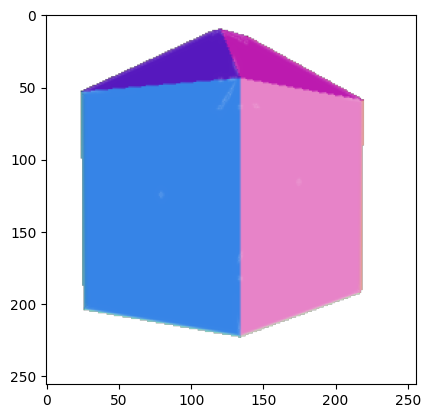

In [20]:
plt.imshow(rendered_normalmap.squeeze().detach().cpu())

torch.return_types.aminmax(
min=tensor(1., device='cuda:0', grad_fn=<NotImplemented>),
max=tensor(1., device='cuda:0', grad_fn=<NotImplemented>))


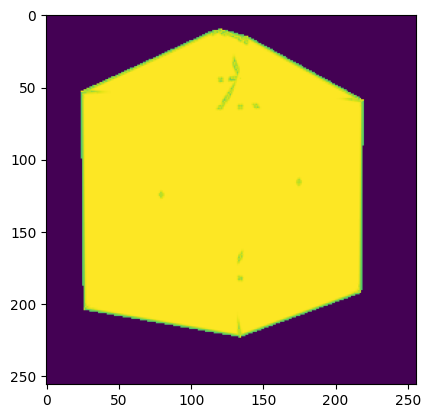

In [21]:
plt.imshow(rendered_silhouette.squeeze().detach().cpu()[...,-1])
print(rendered_silhouette[...,1].aminmax())

torch.Size([1, 256, 256, 2])


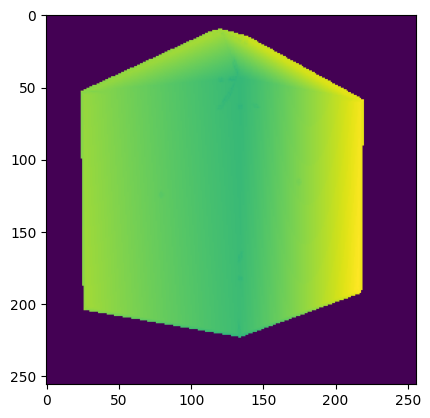

In [22]:
plt.imshow(rendered_normalized_depth[...,0].squeeze().detach().cpu())
print(rendered_normalized_depth.shape)

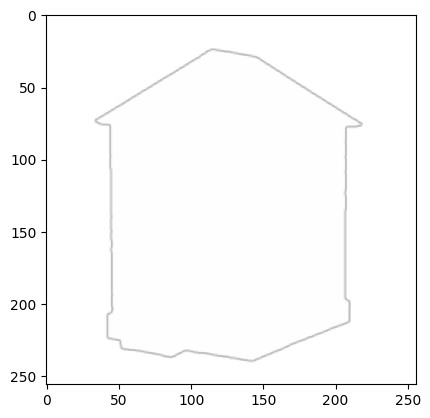

In [23]:
plt.imshow(nalpha.squeeze().unsqueeze(-1).mul(torch.tensor([1,1,1,1])))

In [24]:
from custom_nodes.comfywr_pytorch_renderkit.optimizations.normalmap_optimization import optimize_mesh_normalmap

target_normalmap = normalmap_rgba.permute(0,2,3,1).float().to(device)

# SGD optimizer: translation (inside transform), sizes, and camera params
params = list(cuboid.parameters()) + list(camera.parameters())
# params = camera.parameters()
# optimizer = torch.optim.SGD(params, lr=lr, momentum=0.9)
optimizer = torch.optim.AdamW(params, lr=lr)

mesh, camera, losses, best_render = optimize_mesh_normalmap(cuboid, camera, renderer_normalmap, target_normalmap, optimizer, early_stop_window = 150, early_stop_percent=1e-5, silhouette_weight=4.0, device=device)
mesh, camera, further_losses, best_render = optimize_mesh_normalmap(cuboid, camera, renderer_normalmap, target_normalmap, optimizer, early_stop_window = 200, early_stop_percent=1e-5, silhouette_weight=4.0, device=device)
masked_target_normalmap = target_normalmap * best_render.select(-1,-1).unsqueeze(-1).gt(0)
params = list(cuboid.parameters())
optimizer = torch.optim.AdamW(params, lr=lr)
mesh, camera, masked_losses, masked_best_render = optimize_mesh_normalmap(cuboid, camera, renderer_normalmap, masked_target_normalmap, optimizer, early_stop_window = 200, early_stop_percent=1e-5, silhouette_weight=1.0, device=device)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:54<00:00, 55.00it/s]


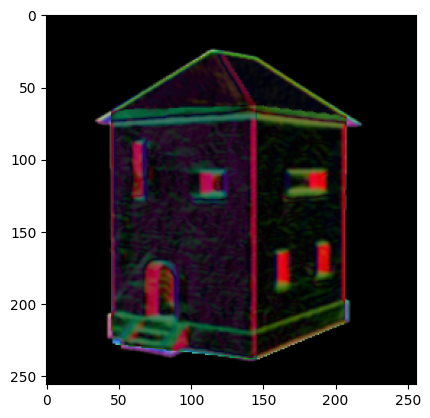

In [25]:
silhs = (masked_best_render - target_normalmap)[0,...,:-1].abs()
plt.imshow(silhs.detach().cpu())

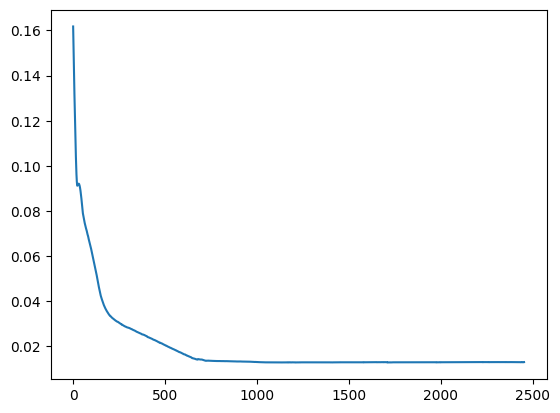

In [26]:
plt.plot(losses+further_losses)

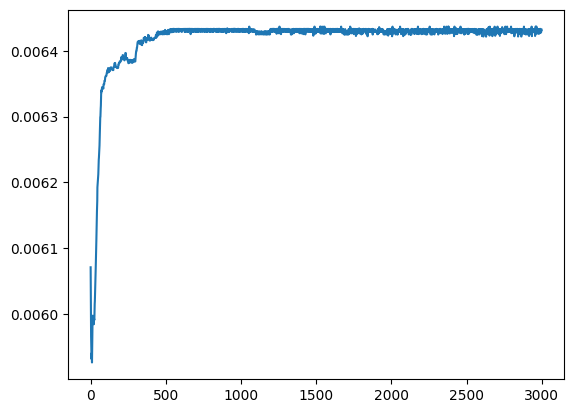

In [27]:
plt.plot(masked_losses)

In [28]:
denorm = lambda n, mn, mx: mn + n * (mx - mn)
camera.fov

tensor([22.5563], device='cuda:0')

In [29]:
camera.denorm(camera.dist_norm, camera.dist_min, camera.dist_max)

tensor([1.4293], device='cuda:0', grad_fn=<AddBackward0>)

In [30]:
camera.dist

tensor([4.1380], device='cuda:0')

In [31]:
camera.offset

Parameter containing:
tensor([[-0.0231,  0.1077, -0.0009]], device='cuda:0', requires_grad=True)

In [32]:
### cuboid.roof_size

In [33]:
cuboid.sizes

Parameter containing:
tensor([0.6763, 0.9784, 0.9310], device='cuda:0', requires_grad=True)

In [34]:
import torch.nn as nn

translation = cuboid.transform.translation.detach()

# Create an MSE loss criterion
criterion = nn.HuberLoss(reduction='mean')

with torch.no_grad():

    # transform = Transform(translation = cuboid.transform.translation.detach(), lock_scale=True, lock_rotation=True)
    # transform.translation[:] = cuboid.transform.translation.detach()
    new_cuboid = RoofedBuilding(*cuboid.sizes, roof_size=tuple(cuboid.roof_size)).to(device)

    new_target_normalmap = normalmap_rgba.permute(0,2,3,1).float().to(device)
    
    x = 0.038
    new_cuboid.sizes[1] -= x
    new_cuboid.transform.translation[1] -= x - 0.01
    new_cuboid.roof_size[1] += 0.068
    new_cuboid.roof_size[2] += 0.18
    # Render the cuboid
    mesh = new_cuboid()
    cams = camera(device)
    new_rendered = renderer_normalmap(meshes_world=mesh, cameras=cams)
    masked_target_normalmap = new_target_normalmap * new_rendered[...,-1].unsqueeze(-1).gt(0)
    new_loss = criterion(new_rendered, masked_target_normalmap)
    mesh = cuboid()
    old_rendered = renderer_normalmap(meshes_world=mesh, cameras=cams)
    masked_target_normalmap = new_target_normalmap * old_rendered[...,-1].unsqueeze(-1).gt(0)
    old_loss = criterion(old_rendered, masked_target_normalmap)

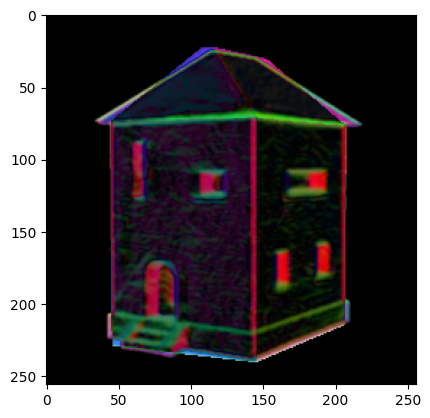

In [35]:
silhs = (new_rendered - target_normalmap)[0,...,:-1].abs()
plt.imshow(silhs.detach().cpu())

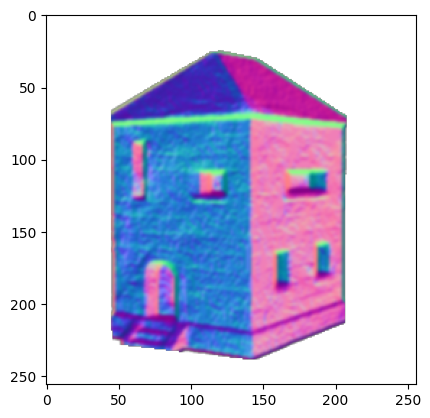

In [36]:
plt.imshow(masked_target_normalmap.squeeze().detach().cpu())

In [37]:
new_target_normalmap = normalmap_rgba.permute(0,2,3,1).float().to(device)

with torch.no_grad():
    mesh = new_cuboid()
    cams = camera(device)
    new_rendered = renderer_normalmap(meshes_world=mesh, cameras=cams)
    masked_target_normalmap = new_target_normalmap * new_rendered[...,-1].unsqueeze(-1).gt(0)
    new_loss = criterion(new_rendered, masked_target_normalmap)
    mesh = cuboid()
    old_rendered = renderer_normalmap(meshes_world=mesh, cameras=cams)
    masked_target_normalmap = new_target_normalmap * old_rendered[...,-1].unsqueeze(-1).gt(0)
    old_loss = criterion(old_rendered, masked_target_normalmap)

tensor([[[0.2624, 0.5178, 0.9396, 1.0000],
         [0.2624, 0.5178, 0.9396, 1.0000],
         [0.2624, 0.5178, 0.9396, 1.0000],
         [0.2624, 0.5178, 0.9396, 1.0000]],

        [[0.2624, 0.5178, 0.9396, 1.0000],
         [0.2624, 0.5178, 0.9396, 1.0000],
         [0.2624, 0.5178, 0.9396, 1.0000],
         [0.2624, 0.5178, 0.9396, 1.0000]],

        [[0.2624, 0.5178, 0.9396, 1.0000],
         [0.2624, 0.5178, 0.9396, 1.0000],
         [0.2624, 0.5178, 0.9396, 1.0000],
         [0.2624, 0.5178, 0.9396, 1.0000]],

        [[0.2624, 0.5178, 0.9396, 1.0000],
         [0.2624, 0.5178, 0.9396, 1.0000],
         [0.2624, 0.5178, 0.9396, 1.0000],
         [0.2624, 0.5178, 0.9396, 1.0000]]])


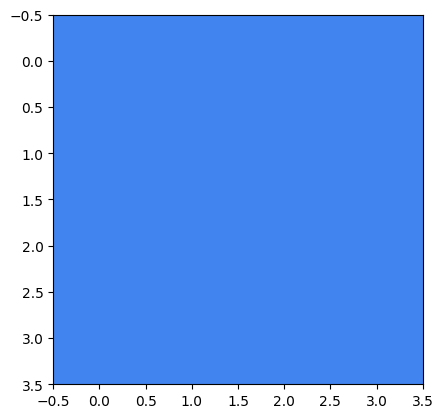

In [38]:
patch = new_rendered.squeeze().detach().cpu()[78:82,58:62]

plt.imshow(patch)
print(patch)

In [39]:
new_loss.item(),old_loss.item()

(0.006634329445660114, 0.0056300656870007515)

In [40]:
c = cuboid.cuboid()

In [41]:
c.sizes

Parameter containing:
tensor([0.6763, 0.9784, 0.9310], device='cuda:0', requires_grad=True)

In [42]:
img_path = "../ComfyUI/input/wierd_windows_building.png"

depth_size = (128,128)

# Load depth map and mask
img = np.array(Image.open(img_path))

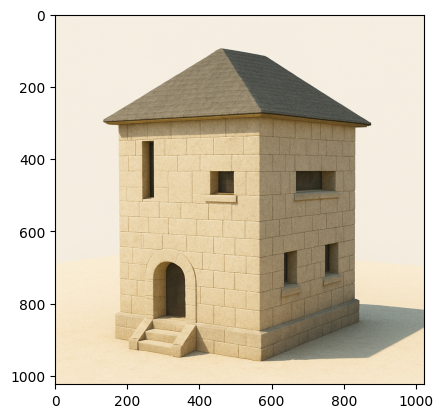

In [43]:
plt.imshow(img)

In [44]:
import torch
from pytorch3d.renderer import (
    MeshRasterizer,
    RasterizationSettings,
    FoVPerspectiveCameras,
    TexturesUV,
)
from pytorch3d.structures import Meshes


def export_mesh_to_pytorch3d(
    mesh,                  # custom Mesh with v, f, vt, ft, albedo
    device: torch.device   # target device for tensors
) -> Meshes:
    """
    Convert a custom mesh object into a PyTorch3D Meshes with UV textures.

    Args:
        mesh: custom Mesh with attributes:
            v: (V, 3) float tensor of vertices
            f: (F, 3) long tensor of face indices into v
            vt: (V_uv, 2) float tensor of UV coords per vertex
            ft: (F, 3) long tensor of face indices into vt
            albedo: (H_tex, W_tex, 3) float tensor of texture image [0..1]
        device: torch.device for output tensors

    Returns:
        mesh_p3d: a Meshes instance with TexturesUV
    """
    # Vertices and faces
    verts = mesh.v.unsqueeze(0).to(device)    # (1, V, 3)
    faces = mesh.f.unsqueeze(0).to(device)    # (1, F, 3)
    # UV coordinates and indices
    verts_uvs = mesh.vt.to(device)           # (V_uv, 2)
    faces_uvs = mesh.ft.to(device)           # (F, 3)
    # Texture map as (1, H_tex, W_tex, 3)
    tex = mesh.albedo.to(device)
    tex_map = tex.permute(2, 0, 1).unsqueeze(0).permute(0, 2, 3, 1)
    # Create TexturesUV and wrap in Meshes
    textures = TexturesUV(
        maps=[tex_map],
        faces_uvs=[faces_uvs],
        verts_uvs=[verts_uvs]
    )
    mesh_p3d = Meshes(verts=verts, faces=faces, textures=textures)
    return mesh_p3d


def reproject_visible_faces(
    meshes: Meshes,               # a PyTorch3D Meshes with UV textures
    camera: FoVPerspectiveCameras,
    reference_image: torch.Tensor,    # (H, W, 3), float RGB [0..1]
    uv_size=(1024, 1024)   # output UV‑map (height, width)
) -> torch.Tensor:
    """
    Re-project visible faces from reference_image into UV-space.
    """
    device = reference_image.device
    H, W = reference_image.shape[:2]

    # Rasterize at reference image resolution
    raster_settings = RasterizationSettings(
        image_size=(H, W), blur_radius=0.0, faces_per_pixel=1
    )
    fragments = MeshRasterizer(cameras=camera, raster_settings=raster_settings)(meshes)
    pix_to_face = fragments.pix_to_face[0, ..., 0]   # (H, W)
    bary_coords = fragments.bary_coords[0, ...]      # (H, W, 3)

    # Interpolate per-pixel UVs using built-in PyTorch3D helper
    # Prepare face_uvs attribute: (F, 3, 2)
    verts_uvs = meshes.textures.verts_uvs_list()[0]  # (V_uv, 2)
    faces_uvs = meshes.textures.faces_uvs_list()[0]  # (F, 3)
    face_uvs = verts_uvs[faces_uvs].squeeze()                  # (F, 3, 2)
    # Use interpolate_face_attributes to get per-pixel UV: (1, H, W, 2)
    uv_map = interpolate_face_attributes(
        fragments.pix_to_face,      # (1, H, W, K)
        fragments.bary_coords,      # (1, H, W, K, 3)
        face_uvs                   # (F, 3, 2)
    )  # returns (1, H, W, 2)
    uv = uv_map[0, ..., 0, :]      # (H, W, 2), first hit

    # Scatter colors into UV canvas
    valid = pix_to_face >= 0
    uvs = uv[valid]                 # (P, 2)
    uv_H, uv_W = uv_size
    uv_img = torch.zeros(uv_H * uv_W, 3, device=device)
    pix_colors = reference_image[valid]
    u_pix = (uvs[:, 0] * (uv_W - 1)).long()
    v_pix = (uvs[:, 1] * (uv_H - 1)).long()
    idx = v_pix * uv_W + u_pix
    uv_img[idx] = pix_colors
    return uv_img.view(uv_H, uv_W, 3)


In [45]:
import xatlas

v_np = cuboid().verts_packed().detach().cpu().numpy()
f_np = cuboid().faces_packed().detach().cpu().numpy()
atlas = xatlas.Atlas()
atlas.add_mesh(v_np, f_np)
chart_options = xatlas.ChartOptions()
# chart_options.max_iterations = 4
atlas.generate(chart_options=chart_options)
vmapping, ft_np, vt_np = atlas[0]

verts_uvs = torch.from_numpy(vt_np).to(device)          # (V_uv, 2)
faces_uvs = torch.from_numpy(ft_np).to(device).long() 

tex_map = torch.zeros(1024,1024,3).to(device).float()
texture = TexturesUV(
        maps=[tex_map],
        faces_uvs=[faces_uvs],
        verts_uvs=[verts_uvs]
    )

mesh = cuboid()
new_meshes = Meshes(verts=mesh.verts_list(),
                    faces=mesh.faces_list(),
                    textures=texture)

reference_image = torch.from_numpy(img/255).to(device).float()

In [46]:
from custom_nodes.comfywr_pytorch_renderkit.utils.reproject_visible_faces import reproject_visible_faces

tex_map = reproject_visible_faces(new_meshes, camera(device), reference_image=reference_image, replace_all=False)

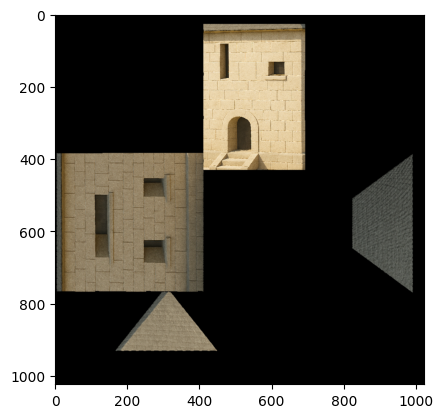

In [47]:
plt.imshow(tex_map.detach().cpu().numpy())